# Everything *except* the rezoning areas — a comparison set from the Housing Database

**SKELETON.** The parts that are mechanical and easy to get subtly wrong are finished and
tested: loading the Housing Database, building the exclusion set from both rezoning BBL
lists, removing it, and aggregating what is left by completion year. The parts that are
analytical judgement — which comparison you actually want — are marked **TODO** and left
for you, because picking them silently would be the wrong call.

**Self-contained**, like its two siblings: every library and function it uses is defined
in it.

## What this is for

`jerome_ave_hdb.ipynb` and `east_ny_hdb.ipynb` each answer "how much housing was completed
here, by year?". On its own that number means very little. Jerome's completions climb
sharply after 2021 — but so did completions across most of the city, because the
2015–2019 permit wave landed then and because 421-a's 2022 deadline pulled a great deal of
construction forward. A rise inside the rezoning area is only evidence *about the
rezoning* if it differs from what happened outside it.

So this notebook produces the **complement**: every Housing Database job that is *not* on
a Jerome Avenue or East New York rezoning parcel. That is the raw material for a
comparison; it is not yet a comparison.

## The exclusion, precisely

A job is excluded if **either** rule fires:

1. its `BBL` is one of the individually listed rezoning lots, **or**
2. its `BBL` sits on one of the listed `0000` tax blocks (first six characters, borough +
   block).

Both rules are needed for the same reason they were needed in the two study notebooks: a
block-level entry is not a lot, and the jobs on it are filed under the individual lot BBLs
that block contains. Excluding only the listed lot BBLs would leave most of the rezoning
construction sitting in the "control" group, which is the one error that would quietly
invert any result built on this table.

The exclusion is deliberately **wider than each notebook's study area**: it removes every
lot on a listed block, including those neither notebook counted. For a control group,
over-excluding is the safe direction — a rezoning-area building left in the comparison
set contaminates it, whereas a nearby building wrongly removed only costs a little
statistical power.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

HDB_PATH = "../data/raw/HousingDB_post2010.csv"
JEROME_CSV = "../data/raw/jerome_rezone_db.csv"
ENY_TXT = "../data/raw/east new york bbls/bbls_east_new_york.txt"
OUT = "citywide_control_hdb"

## Toolbox
Trimmed to what this notebook needs. `load_housingdb` and `hdb_by_year` are the same
functions as in the two study notebooks — deliberately, so the control numbers and the
study numbers are produced by identical code and can be compared without an asterisk.

In [2]:
HDB_KEEP = ["Job_Number", "Job_Type", "Job_Status", "BIN", "BBL", "Boro", "AddressNum",
            "AddressSt", "CompltYear", "PermitYear", "ClassAInit", "ClassAProp",
            "ClassANet", "Units_CO", "DateFiled", "DatePermit", "DateComplt",
            "Bldg_Class", "Job_Desc", "Latitude", "Longitude", "CommntyDst", "CouncilDst",
            "NTA2020", "NTAName20"]
HDB_NUM = ["CompltYear", "PermitYear", "ClassAInit", "ClassAProp", "ClassANet",
           "Units_CO", "Latitude", "Longitude"]


def load_housingdb(path):
    """Load the Housing Database, typed, with the two derived columns everything uses.

    Read as **strings**: `BBL` is 10 digits and `BIN` is 7, and either becomes garbage as a
    float. This variant also keeps the geography columns (`CommntyDst`, `CouncilDst`,
    `NTA2020`), which the study notebooks do not need but a comparison scope will.
    """
    hdb = pd.read_csv(path, dtype=str, low_memory=False)
    absent = [c for c in HDB_KEEP if c not in hdb.columns]
    if absent:
        raise ValueError(f"HousingDB is missing expected columns: {absent}")
    hdb = hdb[HDB_KEEP].copy()
    for c in HDB_NUM:
        hdb[c] = pd.to_numeric(hdb[c], errors="coerce")
    hdb["BBL"] = hdb["BBL"].fillna("").str.strip()
    hdb["BIN"] = hdb["BIN"].fillna("").str.strip()
    hdb["hdb_completed"] = hdb["Job_Status"].str[0].isin(["4", "5"])
    hdb["hdb_address"] = (hdb["AddressNum"].fillna("") + " "
                          + hdb["AddressSt"].fillna("")).str.strip()
    print("HousingDB rows:", len(hdb), "| distinct BBL:", hdb["BBL"].nunique(),
          "| distinct BIN:", hdb["BIN"].nunique(), "| completed:",
          int(hdb["hdb_completed"].sum()))
    return hdb


def is_block_bbl(bbl):
    """A BBL whose lot part is `0000` is a whole tax block, not a real lot."""
    return bbl.endswith("0000")


def exclusion_set(*bbl_lists):
    """
    Build the (lots, blocks) exclusion keys from one or more raw BBL lists.

    Blocks are returned as **six**-character prefixes (borough + 5-digit block). Cutting to
    seven would include the first digit of the lot and exclude almost nothing — the failure
    mode this function exists to make impossible to reproduce by hand.
    """
    all_bbls = sorted({b for lst in bbl_lists for b in lst})
    bad = [b for b in all_bbls if len(b) != 10 or not b.isdigit()]
    if bad:
        raise ValueError(f"malformed BBLs (expected 10 digits): {bad[:5]}")
    lots = {b for b in all_bbls if not is_block_bbl(b)}
    blocks = {b[:6] for b in all_bbls if is_block_bbl(b)}
    print(f"exclusion keys: {len(lots)} individual lots | {len(blocks)} tax blocks")
    return lots, blocks


def split_out_rezoning(hdb, lots, blocks):
    """
    Split the Housing Database into (control, rezoning) on the two exclusion rules.

    Returns both halves rather than only the complement, because the discarded half is what
    proves the exclusion did what it claims — if `rezoning` does not roughly match the two
    study notebooks' job counts, the keys are wrong and the control is contaminated.
    """
    on_lot = hdb["BBL"].isin(lots)
    on_block = hdb["BBL"].str[:6].isin(blocks)
    hit = on_lot | on_block

    rez = hdb[hit].copy()
    rez["excluded_via"] = on_lot[rez.index].map({True: "bbl", False: "bbl_block"})
    ctl = hdb[~hit].copy()

    print(f"rezoning-area jobs removed: {len(rez):,}"
          f" ({rez['excluded_via'].value_counts().to_dict()})")
    print(f"control jobs remaining:     {len(ctl):,} of {len(hdb):,}")
    return ctl, rez


def hdb_by_year(scoped, first=2010):
    """Units and buildings per completion year, completed jobs only.

    Identical to the function in the two study notebooks, so control and study series are
    produced by the same code. `net_units` is Σ `ClassANet` across all job types, so the
    negative units a completed demolition carries are subtracted.
    """
    d = scoped[scoped["hdb_completed"] & scoped["CompltYear"].notna()].copy()
    d = d[d["CompltYear"] >= first]
    if not len(d):
        raise ValueError(f"no completed jobs with a CompltYear >= {first}")
    d["CompltYear"] = d["CompltYear"].astype(int)

    nbj = d[d["Job_Type"] == "New Building"]
    dmj = d[d["Job_Type"] == "Demolition"]
    out = pd.DataFrame(index=pd.Index(range(first, int(d["CompltYear"].max()) + 1),
                                      name="year"))
    out["net_units"] = d.groupby("CompltYear")["ClassANet"].sum()
    out["nb_units"] = nbj.groupby("CompltYear")["ClassANet"].sum()
    out["demo_units"] = dmj.groupby("CompltYear")["ClassANet"].sum()
    out["buildings"] = d.groupby("CompltYear")["BIN"].nunique()
    out["nb_buildings"] = nbj.groupby("CompltYear")["BIN"].nunique()
    out["demolished"] = dmj.groupby("CompltYear")["BIN"].nunique()
    out["jobs"] = d.groupby("CompltYear").size()
    return out.fillna(0).astype(int)


INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#ffffff"
SERIES_1, SERIES_2 = "#2a78d6", "#eb6834"


def _chrome(ax, years, ylabel):
    ax.set_ylabel(ylabel, fontsize=10, color=INK2)
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
    ax.set_xticks(list(years))
    ax.set_xticklabels([str(y) for y in years], rotation=45, ha="right", fontsize=9)
    ax.tick_params(colors=MUTED, length=0)
    ax.grid(axis="y", color=GRID, lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)


def indexed_chart(series, rezone_year, title, base_year=None):
    """
    Study area vs. control, **indexed to a common base year**.

    This is the one chart shape that answers the question. The control is the whole city
    and the study areas are a few blocks, so their raw unit counts differ by three orders
    of magnitude — plotting them together on one axis shows nothing, and giving them two
    axes would be worse, because the reader would see whatever relationship the scale
    choice implied. Indexing both to 100 in a shared pre-rezoning base year puts them on
    one honest axis where the only thing being compared is *shape*.

    `series` is a dict of `{label: pandas Series indexed by year}`. Colour follows the
    entity in fixed order, never rank.
    """
    base_year = base_year or (rezone_year - 1)
    years = sorted({y for s in series.values() for y in s.index})
    fig, ax = plt.subplots(figsize=(11, 4.6))

    for (label, s), colour in zip(series.items(), [SERIES_1, SERIES_2]):
        s = s.reindex(years, fill_value=0).astype(float)
        base = s.loc[:base_year].tail(3).mean()      # 3-year base, so one odd year cannot set it
        if base <= 0:
            print(f"  WARNING: '{label}' has no positive base around {base_year}; not indexed")
            continue
        ax.plot(years, s / base * 100, lw=2, color=colour, label=label, zorder=3)

    ax.axhline(100, color=AXIS, lw=1, zorder=2)
    ax.axvline(rezone_year - 0.5, color=MUTED, lw=1, zorder=2)
    ax.text(rezone_year - 0.4, ax.get_ylim()[1] * 0.96, f"{rezone_year} rezoning",
            color=MUTED, fontsize=9, va="top")
    ax.set_title(title, fontsize=13, color=INK, pad=12, loc="left")
    _chrome(ax, years, f"completions, indexed (100 = {base_year - 2}–{base_year} mean)")
    ax.legend(frameon=False, fontsize=9, labelcolor=INK2, loc="upper left")
    fig.tight_layout()
    plt.show()


def save_csv(df, name, outdir="."):
    p = Path(outdir).resolve() / f"{name}.csv"
    df.to_csv(p, index=False)
    print("saved:", df.shape, "->", p)
    return p

## 1. Load the two rezoning BBL lists and build the exclusion set
Jerome contributes its 27 tax blocks (from the Admin Code appendix) **and** the 188
individually mapped lot BBLs; East New York contributes all 50 entries from
`bbls_east_new_york.txt` — 14 lots and 36 blocks.

Both are included at full width on purpose: the aim is that no job on a rezoning parcel
survives into the control set, even if neither study notebook happened to count it.

In [3]:
rezone = pd.read_csv(JEROME_CSV, dtype=str)
jerome_lots = sorted({"2" + r.Block.zfill(5) + r.Lot.zfill(4) for r in rezone.itertuples()})
jerome_blocks = sorted({"2" + b.zfill(5) + "0000" for b in rezone["Block"]})

with open(ENY_TXT) as f:
    eny_bbls = sorted({ln.strip() for ln in f if ln.strip()})

print("Jerome:", len(jerome_lots), "mapped lots on", len(jerome_blocks), "blocks")
print("East New York:", len(eny_bbls), "entries")

EXCL_LOTS, EXCL_BLOCKS = exclusion_set(jerome_lots, jerome_blocks, eny_bbls)

Jerome: 188 mapped lots on 27 blocks
East New York: 50 entries
exclusion keys: 202 individual lots | 63 tax blocks


## 2. Split the Housing Database
Both halves are kept. The removed half is the check on the exclusion: it should land in
the same neighbourhood as the two study notebooks' scoped job counts (Jerome ~101 on its
27 blocks, East New York ~91 on its 50 entries), plus the extra lots this wider rule
sweeps in. If it comes back near zero, the block prefixes are wrong and the control set is
contaminated — which is a silent failure, so it is asserted rather than eyeballed.

In [4]:
hdb = load_housingdb(HDB_PATH)
control, rezoning = split_out_rezoning(hdb, EXCL_LOTS, EXCL_BLOCKS)

assert len(rezoning) > 150, "exclusion removed implausibly little — check the block prefixes"
assert len(control) + len(rezoning) == len(hdb), "the split lost or duplicated rows"

print("\nremoved jobs by borough:", rezoning["Boro"].value_counts().to_dict())
print("removed jobs by community district:",
      rezoning["CommntyDst"].value_counts().head(6).to_dict())

save_csv(control, f"{OUT}_control_jobs")
_ = save_csv(rezoning, f"{OUT}_excluded_rezoning_jobs")

HousingDB rows: 81708 | distinct BBL: 68190 | distinct BIN: 71408 | completed: 66508
rezoning-area jobs removed: 192 ({'bbl_block': 177, 'bbl': 15})
control jobs remaining:     81,516 of 81,708

removed jobs by borough: {'2': 101, '3': 91}
removed jobs by community district: {'305': 91, '205': 49, '204': 45, '207': 7}


saved: (81516, 27) -> C:\Users\arian\Documents\fable_housing\notebooks\citywide_control_hdb_control_jobs.csv
saved: (192, 28) -> C:\Users\arian\Documents\fable_housing\notebooks\citywide_control_hdb_excluded_rezoning_jobs.csv


## 3. The control series, by completion year
Citywide completions with both rezoning areas removed. This is the "what was happening
anyway" baseline — and looking at it before choosing a comparison is worth the minute it
takes, because the citywide shape (the post-2021 surge, the 421-a deadline effect) is
exactly what a naive reading of the study-area charts would otherwise attribute to the
rezonings.

**The last year in the table is partial.** The Housing Database is a snapshot, so the
current year holds only the jobs signed off before the extract was cut — a handful of
rows against tens of thousands in a full year. Left in a comparison it reads as a
collapse in construction that is really just the calendar. It is printed here so it is
visible, and dropped from anything that gets compared.

In [5]:
control_by_year = hdb_by_year(control, first=2010)
print(control_by_year.to_string())
_ = save_csv(control_by_year.reset_index(), f"{OUT}_control_by_year")

# the partial current year, excluded from every comparison below
LAST_FULL_YEAR = int(control_by_year.index.max()) - 1
print(f"\nlast full year: {LAST_FULL_YEAR}"
      f" | {int(control_by_year.index.max())} is partial"
      f" ({control_by_year.loc[control_by_year.index.max(), 'jobs']} jobs) and is dropped")
control_by_year = control_by_year.loc[:LAST_FULL_YEAR]

      net_units  nb_units  demo_units  buildings  nb_buildings  demolished  jobs
year                                                                            
2010      23337     22683        -897       5009          2197         448  5058
2011      17904     17230        -873       4382          1696         451  4440
2012      10570      9686       -1055       3982          1360         515  4023
2013      14536     14443       -1361       3972          1295         633  4027
2014      12456     13168       -1548       3925          1271         770  3989
2015      15580     15588       -2348       4166          1411         843  4282
2016      23725     23448       -2008       4647          1694         942  4777
2017      26300     25328       -2157       4806          1663        1009  4887
2018      29136     28548       -1654       4494          1656         826  4593
2019      26713     24672       -2013       4666          1657         802  4782
2020      21089     19924   

## 4. TODO — choose the comparison scope
Citywide is the widest possible control and almost certainly **not** the one you want: it
compares a few rezoned blocks in the west Bronx against Manhattan towers and Staten Island
subdivisions. Narrow it to somewhere that plausibly shares the study area's housing market
and would have moved the same way absent the rezoning.

The geography columns are already loaded (`CommntyDst`, `CouncilDst`, `NTA2020`,
`NTAName20`). Pick one and fill in the filter:

| option | filter | trade-off |
|---|---|---|
| same community district | `CommntyDst in ("204", "205")` for Jerome, `"305"` for East New York | closest market match; small n, and it may contain spillover from the rezoning itself |
| adjacent community districts | a hand-picked list of neighbouring CDs | avoids spillover; assumes the neighbours are comparable |
| same borough | `Boro == "2"` / `"3"` | large n; weak comparability |
| citywide | no filter (§3 as it stands) | largest n; weakest comparability |

A caution worth writing down before you pick: whatever you choose, this is a
**descriptive** comparison, not a causal estimate. A rezoning is not assigned at random —
the city rezones places it expects to develop — so a difference between study and control
is consistent with the rezoning having worked *and* with the city having correctly
predicted where growth was coming. `nb07_src.py` is where the difference-in-differences
machinery lives if you want to go further than description.

In [6]:
# TODO: set the comparison scope, e.g.
#   comparison = control[control["CommntyDst"].isin(["204", "205"])]
comparison = control          # <- citywide placeholder; narrow this
comparison_by_year = hdb_by_year(comparison, first=2010).loc[:LAST_FULL_YEAR]

## 5. TODO — load a study series and compare
Reads the by-year CSV either study notebook wrote, so this notebook never re-does their
work and cannot drift from them. Run `jerome_ave_hdb.ipynb` or `east_ny_hdb.ipynb` first.

The chart indexes both series to 100 at a pre-rezoning base, because the control is
thousands of units a year and a study area is dozens — on one raw axis the study area is a
flat line at the bottom, and on two axes the reader sees whatever the scale choice
implied. Indexed, the only thing being compared is the shape, which is the question.

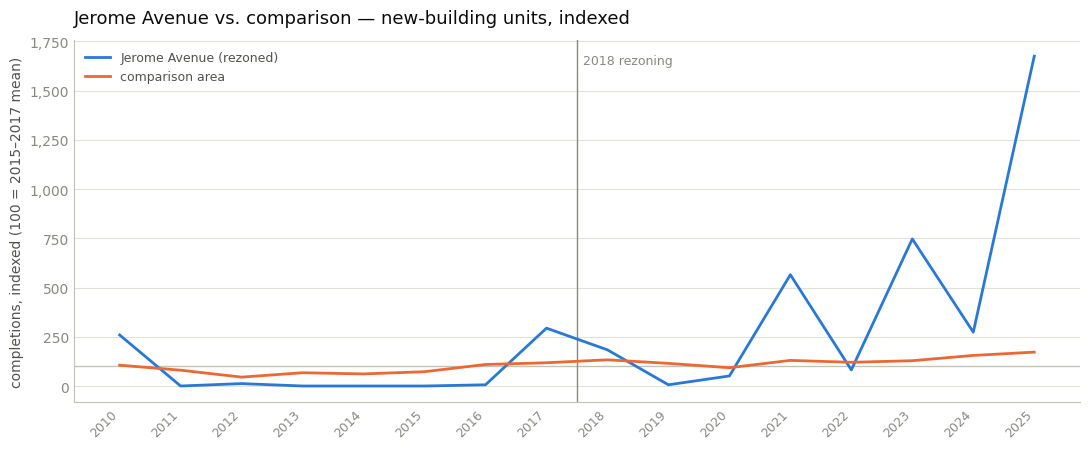

In [7]:
# TODO: pick the study area this comparison is for
STUDY_CSV, STUDY_LABEL, REZONE_YEAR = "jerome_ave_hdb_by_year.csv", "Jerome Avenue", 2018
# STUDY_CSV, STUDY_LABEL, REZONE_YEAR = "east_ny_hdb_by_year.csv", "East New York", 2016

if Path(STUDY_CSV).exists():
    study_by_year = pd.read_csv(STUDY_CSV).set_index("year")
    indexed_chart(
        {f"{STUDY_LABEL} (rezoned)": study_by_year["nb_units"],
         "comparison area": comparison_by_year["nb_units"]},
        REZONE_YEAR,
        f"{STUDY_LABEL} vs. comparison — new-building units, indexed")
else:
    print(f"{STUDY_CSV} not found — run the study notebook first, then re-run this cell")

## 6. TODO — the rest
Left deliberately empty. Things that belong here once §4 and §5 are settled:

- **Normalise for size.** Units per 1,000 existing residential units, or per acre of lot
  area, so a study area of 27 blocks and a comparison of a whole district are on
  comparable footing. Needs a denominator pulled from PLUTO.
- **Match on pre-period trend** rather than just geography — restrict the comparison to
  tracts or districts whose 2010–2015 completion trajectory resembles the study area's.
  This is what makes a parallel-trends assumption arguable instead of assumed.
- **Permit year as well as completion year.** `PermitYear` moves three to five years
  earlier than `CompltYear` and is the series that responds to a rezoning first; the two
  together separate "approved more" from "delivered more".
- **Split by affordability.** The Housing Database does not carry income tiers — join HPD
  `hg8x-zxpr` on BBL if the MIH question matters.